# Experiment: DistilBERT Reddit Comment-Only vs Paired Context

This notebook fine-tunes `distilbert-base-uncased` on the same cleaned Reddit split used by the non-pretrained benchmark.

Compared input modes:
- `comment_only`
- `paired_context`, where the parent comment is passed as `text` and the reply as `text_pair`

The sampled row ids are held fixed so the comparison isolates the effect of pretrained modeling and paired-input context.


## 1. Setup

This notebook is Colab-oriented but still supports local Jupyter execution. Recommended runtime:

- GPU for actual fine-tuning
- CPU only for quick inspection or dry-run validation

The code defaults to CUDA automatically when a GPU is available.


In [14]:
%pip install -q pandas numpy scikit-learn matplotlib seaborn torch transformers accelerate


In [15]:
# Path configuration for local Jupyter or Google Colab.
from pathlib import Path

try:
    import google.colab  # type: ignore
    from google.colab import drive  # type: ignore

    IN_COLAB = True
except ImportError:
    drive = None
    IN_COLAB = False

RUN_CONTEXT = "auto"  # one of: "auto", "local", "colab_drive"
MANUAL_PROJECT_ROOT = None
MANUAL_REDDIT_TRAIN_PATH = None

REDDIT_TRAIN_RELATIVE_CANDIDATES = [
    Path("Dataset") / "Reddit" / "train-balanced-sarcasm.csv",
    Path("Dataset") / "Reddit" / "train-balanced-sarc.csv.gz",
    Path("Dataset") / "Reddit" / "train-balanced-sarc.csv" / "train-balanced-sarc.csv",
]


def mount_drive_if_needed() -> None:
    if IN_COLAB and drive is not None and RUN_CONTEXT in {"auto", "colab_drive"}:
        drive.mount("/content/drive", force_remount=False)


def unique_paths(paths) -> list[Path]:
    seen = set()
    result = []
    for path in paths:
        if path is None:
            continue
        candidate = Path(path).expanduser()
        key = str(candidate)
        if key not in seen:
            seen.add(key)
            result.append(candidate)
    return result


def find_reddit_train_under_root(project_root: Path | None) -> Path | None:
    if project_root is None:
        return None
    root = Path(project_root).expanduser()
    for relative_path in REDDIT_TRAIN_RELATIVE_CANDIDATES:
        candidate = root / relative_path
        if candidate.exists():
            return candidate.resolve()
    return None


def resolve_project_root_from_train_path(train_path: Path | None) -> Path | None:
    if train_path is None:
        return None
    resolved_train_path = Path(train_path).expanduser().resolve()
    for parent in unique_paths([resolved_train_path.parent, *resolved_train_path.parents]):
        matched_train_path = find_reddit_train_under_root(parent)
        if matched_train_path is not None and matched_train_path.resolve() == resolved_train_path:
            return parent.resolve()
    return None


def discover_project_root() -> Path | None:
    direct_root = resolve_project_root_from_train_path(find_reddit_train_under_root(MANUAL_PROJECT_ROOT))
    if direct_root is not None:
        return direct_root

    direct_from_train = resolve_project_root_from_train_path(MANUAL_REDDIT_TRAIN_PATH)
    if direct_from_train is not None:
        return direct_from_train

    candidate_roots = [Path.cwd(), *Path.cwd().parents]
    if IN_COLAB and RUN_CONTEXT in {"auto", "colab_drive"}:
        candidate_roots.extend(
            [
                Path("/content"),
                Path("/content/drive"),
                Path("/content/drive/MyDrive"),
            ]
        )
    else:
        candidate_roots.extend(
            [
                Path.home(),
                Path.home() / "Documents",
                Path.home() / "Downloads",
            ]
        )

    for candidate_root in unique_paths(candidate_roots):
        matched_train_path = find_reddit_train_under_root(candidate_root)
        if matched_train_path is not None:
            return candidate_root.resolve()

    search_roots = [Path.cwd(), *Path.cwd().parents]
    if IN_COLAB:
        search_roots.extend([Path("/content"), Path("/content/drive"), Path("/content/drive/MyDrive")])
    else:
        search_roots.extend([Path.home(), Path.home() / "Documents", Path.home() / "Downloads"])

    for search_root in unique_paths(search_roots):
        if not search_root.exists():
            continue
        try:
            for pattern in ("train-balanced-sarcasm.csv", "train-balanced-sarc.csv.gz", "train-balanced-sarc.csv"):
                for match in search_root.rglob(pattern):
                    resolved_root = resolve_project_root_from_train_path(match)
                    if resolved_root is not None:
                        return resolved_root
        except (OSError, PermissionError):
            continue
    return None


mount_drive_if_needed()
PROJECT_ROOT = discover_project_root()

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root automatically. Set MANUAL_PROJECT_ROOT to the repository root "
        "or MANUAL_REDDIT_TRAIN_PATH to a Reddit training file, then rerun this cell. "
        f"Current working directory: {Path.cwd()}"
    )

REDDIT_TRAIN_PATH = find_reddit_train_under_root(PROJECT_ROOT)
if REDDIT_TRAIN_PATH is None:
    raise FileNotFoundError(
        "A Reddit training file was not found under Dataset/Reddit/. "
        "Supported names are train-balanced-sarcasm.csv, train-balanced-sarc.csv.gz, "
        "and train-balanced-sarc.csv/train-balanced-sarc.csv."
    )

UNUSED_REDDIT_TEST_PATHS = [
    PROJECT_ROOT / "Dataset" / "Reddit" / "test-balanced.csv",
    PROJECT_ROOT / "Dataset" / "Reddit" / "test-unbalanced.csv",
]
OUTPUT_ROOT = PROJECT_ROOT / "Notebooks" / "jupyter-notebook"
NOTEBOOK_OUTPUT_PATH = OUTPUT_ROOT / "reddit-sarcasm-distilbert-comment-vs-context-colab.ipynb"

print(f"Project root: {PROJECT_ROOT}")
print(f"Reddit training source: {REDDIT_TRAIN_PATH}")
print("Optional Reddit test files:")
for test_path in UNUSED_REDDIT_TEST_PATHS:
    print(f"  - {test_path}")

PRIOR_NOTEBOOK_PATH = OUTPUT_ROOT / "reddit-sarcasm-comment-vs-context-colab.ipynb"
print(f"Prior custom Reddit notebook reference: {PRIOR_NOTEBOOK_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/UNI/AdvancedMachineLearning/Project
Reddit training source: /content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Dataset/Reddit/train-balanced-sarcasm.csv
Prior custom Reddit notebook reference: /content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Notebooks/jupyter-notebook/reddit-sarcasm-comment-vs-context-colab.ipynb


In [16]:
# Imports, reproducibility, and experiment configuration
from __future__ import annotations

import html
import json
import math
import pickle
import random
import re
import unicodedata
import warnings
from textwrap import dedent

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)
from transformers.utils import logging as hf_logging

warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

MODEL_NAME = "distilbert-base-uncased"
LABEL_NAMES = {0: "not_sarcastic", 1: "sarcastic"}
MODE_ORDER = ["comment_only", "paired_context"]
MODE_SETTINGS = {
    "comment_only": {
        "max_length": 96,
        "description": "tokenize normalized comment text only",
    },
    "paired_context": {
        "max_length": 192,
        "description": "tokenize normalized parent comment as text and normalized reply as text_pair",
    },
}
CONFIG = {
    "seed": SEED,
    "sample_train_size": 200_000,
    "sample_validation_size": 20_000,
    "sample_test_size": 20_000,
    "batch_size": 16,
    "gradient_accumulation_steps": 4,
    "effective_batch_size": 64,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "epochs": 3,
    "warmup_ratio": 0.1,
    "max_grad_norm": 1.0,
    "early_stopping_patience": 1,
    "resume_from_checkpoint": True,
    "reuse_finished_mode_artifact": True,
    "save_checkpoint_every_epoch": True,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option("display.max_colwidth", 220)

DISTILBERT_CHECKPOINT_ROOT = (
    OUTPUT_ROOT
    / "checkpoints"
    / "reddit-sarcasm-distilbert-comment-vs-context"
)
DISTILBERT_CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Checkpoint root: {DISTILBERT_CHECKPOINT_ROOT}")

display(Markdown("### Active configuration"))
pd.DataFrame([CONFIG]).T.rename(columns={0: "value"})


Using device: cuda
GPU: Tesla T4
Checkpoint root: /content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Notebooks/jupyter-notebook/checkpoints/reddit-sarcasm-distilbert-comment-vs-context


### Active configuration

,value
seed,7
sample_train_size,200000
sample_validation_size,20000
sample_test_size,20000
batch_size,16
gradient_accumulation_steps,4
effective_batch_size,64
learning_rate,0.00002
weight_decay,0.01
epochs,3


## 2. Relationship To The Non-Pretrained Benchmark

The notebook reuses the same cleaned split and row identities as the custom-model Reddit benchmark. This makes it possible to compare pretrained fine-tuning against the best non-pretrained result under matched data conditions.


## 3. Data Loading And Cleaning

We reuse the same Reddit source and cleaning rules as the existing notebook:

- load `Dataset/Reddit/train-balanced-sarcasm.csv`
- keep `label`, `comment`, `parent_comment`, `subreddit`, and `score`
- drop empty `comment` rows
- deduplicate exact `(label, comment, parent_comment)` rows
- preserve the full `parent_comment` without pre-truncating raw text


In [17]:
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
USER_PATTERN = re.compile(r"(?<!\w)(?:/?u/\w+|@\w+)")
WHITESPACE_PATTERN = re.compile(r"\s+")


def normalize_text(text: str) -> str:
    """Normalize text while preserving punctuation and discourse markers."""
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""

    cleaned = str(text)
    for _ in range(2):
        cleaned = html.unescape(cleaned)
    cleaned = unicodedata.normalize("NFKC", cleaned)
    cleaned = cleaned.lower()
    cleaned = URL_PATTERN.sub(" <url> ", cleaned)
    cleaned = USER_PATTERN.sub(" <user> ", cleaned)
    cleaned = WHITESPACE_PATTERN.sub(" ", cleaned).strip()
    return cleaned


def load_reddit_data(csv_path: Path) -> tuple[pd.DataFrame, dict]:
    """Load the Reddit CSV with the shared cleaning rules."""
    use_columns = ["label", "comment", "parent_comment", "subreddit", "score"]
    raw_df = pd.read_csv(csv_path, usecols=use_columns, low_memory=False)
    raw_df = raw_df.reset_index().rename(columns={"index": "source_row_id"})

    raw_df["label"] = raw_df["label"].astype(int)
    for column in ["comment", "parent_comment", "subreddit"]:
        raw_df[column] = raw_df[column].fillna("").astype(str)
    raw_df["score"] = pd.to_numeric(raw_df["score"], errors="coerce").fillna(0.0)

    initial_rows = len(raw_df)
    nonempty_mask = raw_df["comment"].str.strip().ne("")
    empty_comment_rows_removed = int((~nonempty_mask).sum())

    cleaned_df = raw_df.loc[
        nonempty_mask,
        ["source_row_id", "label", "comment", "parent_comment", "subreddit", "score"],
    ].copy()
    before_dedup_rows = len(cleaned_df)
    cleaned_df = cleaned_df.drop_duplicates(
        subset=["label", "comment", "parent_comment"],
        keep="first",
    ).copy()
    duplicate_rows_removed = before_dedup_rows - len(cleaned_df)

    cleaned_df["row_id"] = np.arange(len(cleaned_df), dtype=np.int64)
    cleaned_df["label_name"] = cleaned_df["label"].map(LABEL_NAMES)

    report = {
        "source_csv": str(csv_path),
        "initial_rows": initial_rows,
        "empty_comment_rows_removed": empty_comment_rows_removed,
        "duplicate_rows_removed": duplicate_rows_removed,
        "rows_after_cleaning": len(cleaned_df),
        "label_0_rows": int((cleaned_df["label"] == 0).sum()),
        "label_1_rows": int((cleaned_df["label"] == 1).sum()),
    }
    return cleaned_df.reset_index(drop=True), report


In [18]:
reddit_df, cleaning_report = load_reddit_data(REDDIT_TRAIN_PATH)

cleaning_summary_df = pd.DataFrame([cleaning_report]).T.rename(columns={0: "value"})
display(cleaning_summary_df)
display(
    reddit_df[
        ["row_id", "source_row_id", "label_name", "subreddit", "score", "comment", "parent_comment"]
    ].head(3)
)

required_rows = (
    CONFIG["sample_train_size"]
    + CONFIG["sample_validation_size"]
    + CONFIG["sample_test_size"]
)
assert cleaning_report["empty_comment_rows_removed"] >= 1, "Expected empty comments to be removed."
assert cleaning_report["duplicate_rows_removed"] >= 1, "Expected duplicate rows to be removed."
assert len(reddit_df) >= required_rows, "Not enough cleaned Reddit rows for the planned sample sizes."


,value
source_csv,/content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Dataset/Reddit/train-balanced-sarcasm.csv
initial_rows,1010826
empty_comment_rows_removed,55
duplicate_rows_removed,802
rows_after_cleaning,1009969
label_0_rows,504910
label_1_rows,505059


,row_id,source_row_id,label_name,subreddit,score,comment,parent_comment
0,0,0,not_sarcastic,politics,2,NC and NH.,"Yeah, I get that argument. At this point, I'd prefer is she lived in NC as well."
1,1,1,not_sarcastic,nba,-4,You do know west teams play against west teams more than east teams right?,The blazers and Mavericks (The wests 5 and 6 seed) did not even carry a good enough record to make the playoffs in the east last year.
2,2,2,not_sarcastic,nfl,3,"They were underdogs earlier today, but since Gronk's announcement this afternoon, the Vegas line has moved to patriots -1",They're favored to win.


## 4. Fixed Split Reconstruction

The sampled experiment split is rebuilt with the same specification as the earlier Reddit benchmark:
- stratified by `label`
- exactly `200k / 20k / 20k`
- `seed = 7`
- identical row ids across both pretrained modes


In [19]:
def build_reddit_sample_split(
    cleaned_df: pd.DataFrame,
    train_size: int = 200_000,
    validation_size: int = 20_000,
    test_size: int = 20_000,
    seed: int = 7,
) -> tuple[dict[str, pd.DataFrame], dict[str, np.ndarray], np.ndarray, pd.DataFrame]:
    """Create one fixed Reddit sample split that can be reused across modes."""
    required_total = train_size + validation_size + test_size
    if len(cleaned_df) < required_total:
        raise ValueError(
            f"Need at least {required_total:,} cleaned rows, found {len(cleaned_df):,}."
        )

    sampled_row_ids, _ = train_test_split(
        cleaned_df["row_id"],
        train_size=required_total,
        stratify=cleaned_df["label"],
        random_state=seed,
    )
    sampled_row_ids = np.sort(np.asarray(sampled_row_ids))

    indexed_df = cleaned_df.set_index("row_id")
    sampled_df = indexed_df.loc[sampled_row_ids].reset_index()

    train_row_ids, holdout_row_ids = train_test_split(
        sampled_df["row_id"],
        train_size=train_size,
        stratify=sampled_df["label"],
        random_state=seed,
    )
    train_row_ids = np.sort(np.asarray(train_row_ids))
    holdout_row_ids = np.sort(np.asarray(holdout_row_ids))
    holdout_df = indexed_df.loc[holdout_row_ids].reset_index()

    validation_row_ids, test_row_ids = train_test_split(
        holdout_df["row_id"],
        train_size=validation_size,
        test_size=test_size,
        stratify=holdout_df["label"],
        random_state=seed,
    )
    split_row_ids = {
        "train": train_row_ids,
        "validation": np.sort(np.asarray(validation_row_ids)),
        "test": np.sort(np.asarray(test_row_ids)),
    }

    split_frames = {}
    summary_rows = []
    for split_name, row_ids in split_row_ids.items():
        frame = indexed_df.loc[row_ids].reset_index().copy()
        split_frames[split_name] = frame
        summary_rows.append(
            {
                "split": split_name,
                "rows": len(frame),
                "sarcastic_share": frame["label"].mean(),
                "label_0_rows": int((frame["label"] == 0).sum()),
                "label_1_rows": int((frame["label"] == 1).sum()),
                "row_id_min": int(frame["row_id"].min()),
                "row_id_max": int(frame["row_id"].max()),
            }
        )

    summary_df = pd.DataFrame(summary_rows)
    return split_frames, split_row_ids, sampled_row_ids, summary_df


In [20]:
sample_splits, split_row_ids, sampled_row_ids, split_summary_df = build_reddit_sample_split(
    reddit_df,
    train_size=CONFIG["sample_train_size"],
    validation_size=CONFIG["sample_validation_size"],
    test_size=CONFIG["sample_test_size"],
    seed=SEED,
)

display(split_summary_df)

assert len(sample_splits["train"]) == 200_000
assert len(sample_splits["validation"]) == 20_000
assert len(sample_splits["test"]) == 20_000
assert len(sampled_row_ids) == 240_000
assert len(np.unique(sampled_row_ids)) == 240_000
assert set(split_row_ids["train"]).isdisjoint(split_row_ids["validation"])
assert set(split_row_ids["train"]).isdisjoint(split_row_ids["test"])
assert set(split_row_ids["validation"]).isdisjoint(split_row_ids["test"])


,split,rows,sarcastic_share,label_0_rows,label_1_rows,row_id_min,row_id_max
0,train,200000,0.500075,99985,100015,9,1009967
1,validation,20000,0.500100,9998,10002,59,1009950
2,test,20000,0.500050,9999,10001,6,1009952


## 5. Pretrained Input Modes

We keep the same normalized text policy as the existing Reddit notebook, but change the way context is presented to the model:

- `comment_only`: tokenize the normalized reply comment only
- `paired_context`: tokenize normalized `parent_comment` as `text` and normalized `comment` as `text_pair`

This notebook does **not** manually concatenate context with a literal separator token.


In [21]:
def prepare_mode_frame(frame: pd.DataFrame, mode: str) -> pd.DataFrame:
    """Create the mode-specific normalized view without changing row ids."""
    prepared = frame[
        ["row_id", "source_row_id", "label", "label_name", "comment", "parent_comment", "subreddit", "score"]
    ].copy()
    prepared["comment_normalized"] = prepared["comment"].map(normalize_text)
    prepared["parent_comment_normalized"] = prepared["parent_comment"].map(normalize_text)

    if mode == "comment_only":
        prepared["mode_text"] = prepared["comment_normalized"]
        prepared["mode_text_pair"] = None
    elif mode == "paired_context":
        prepared["mode_text"] = prepared["parent_comment_normalized"]
        prepared["mode_text_pair"] = prepared["comment_normalized"]
    else:
        raise ValueError(f"Unknown mode: {mode}")

    prepared["mode"] = mode
    prepared["approx_character_count"] = (
        prepared["mode_text"].str.len()
        + prepared["mode_text_pair"].fillna("").str.len()
    )
    return prepared


def tokenize_mode_batch(
    tokenizer,
    texts: list[str],
    mode: str,
    max_length: int,
    text_pairs: list[str] | None = None,
) -> dict[str, list[list[int]]]:
    """Tokenize one batch for the requested pretrained input mode."""
    if mode == "comment_only":
        return tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding=False,
        )
    if mode == "paired_context":
        if text_pairs is None:
            raise ValueError("paired_context requires text_pairs.")
        return tokenizer(
            text=texts,
            text_pair=text_pairs,
            truncation=True,
            max_length=max_length,
            padding=False,
        )
    raise ValueError(f"Unknown mode: {mode}")


In [22]:
mode_split_frames = {
    mode_name: {
        split_name: prepare_mode_frame(split_frame, mode_name)
        for split_name, split_frame in sample_splits.items()
    }
    for mode_name in MODE_ORDER
}

for split_name in ["train", "validation", "test"]:
    comment_ids = mode_split_frames["comment_only"][split_name]["row_id"].to_numpy()
    paired_ids = mode_split_frames["paired_context"][split_name]["row_id"].to_numpy()
    assert np.array_equal(comment_ids, paired_ids), f"Row ids diverged for {split_name}."
    assert mode_split_frames["comment_only"][split_name]["mode_text_pair"].isna().all()
    assert mode_split_frames["paired_context"][split_name]["mode_text_pair"].notna().all()
    assert not mode_split_frames["comment_only"][split_name]["mode_text"].str.contains("<sep>", regex=False).any()
    assert not mode_split_frames["paired_context"][split_name]["mode_text"].str.contains("<sep>", regex=False).any()
    assert not mode_split_frames["paired_context"][split_name]["mode_text_pair"].str.contains("<sep>", regex=False).any()

mode_summary_rows = []
for mode_name in MODE_ORDER:
    for split_name, split_frame in mode_split_frames[mode_name].items():
        mode_summary_rows.append(
            {
                "mode": mode_name,
                "split": split_name,
                "rows": len(split_frame),
                "sarcastic_share": split_frame["label"].mean(),
                "avg_characters": split_frame["approx_character_count"].mean(),
                "max_length": MODE_SETTINGS[mode_name]["max_length"],
            }
        )

mode_summary_df = pd.DataFrame(mode_summary_rows)
display(mode_summary_df)
display(
    mode_split_frames["paired_context"]["train"][
        ["row_id", "subreddit", "parent_comment", "comment", "mode_text", "mode_text_pair"]
    ].head(3)
)


,mode,split,rows,sarcastic_share,avg_characters,max_length
0,comment_only,train,200000,0.500075,56.821260,96
1,comment_only,validation,20000,0.500100,56.513200,96
2,comment_only,test,20000,0.500050,56.630650,96
3,paired_context,train,200000,0.500075,189.973325,192
4,paired_context,validation,20000,0.500100,187.940000,192
5,paired_context,test,20000,0.500050,190.888050,192


,row_id,subreddit,parent_comment,comment,mode_text,mode_text_pair
0,9,Lollapalooza,"Probably count Kanye out Since the rest of his tour is canceled, it doesn't seem in the cards. But he's also so unpredictable, it could change. Thankfully I saw him before he started canceling shows, going on long ra...",I would love to see him at lolla.,"probably count kanye out since the rest of his tour is canceled, it doesn't seem in the cards. but he's also so unpredictable, it could change. thankfully i saw him before he started canceling shows, going on long ra...",i would love to see him at lolla.
1,11,baseball,James Shields Will Not Exercise Opt-Out Clause,Damn I was hoping God was real,james shields will not exercise opt-out clause,damn i was hoping god was real
2,12,exmormon,There's no time to worry about leaks when they gays are already out to get you.,They have an agenda.,there's no time to worry about leaks when they gays are already out to get you.,they have an agenda.


## 6. DistilBERT Training Utilities

Both modes share the same fine-tuning protocol:
- `distilbert-base-uncased`
- dynamic padding with `DataCollatorWithPadding`
- batch size `16`, gradient accumulation `4`, effective batch size `64`
- learning rate `2e-5`, weight decay `0.01`
- `3` epochs, warmup ratio `0.1`
- best in-session checkpoint chosen by validation F1
- early stopping after `1` non-improving epoch


In [23]:
PRIOR_REDDIT_REFERENCE_RESULTS = [
    {
        "source": "Prior custom Reddit notebook",
        "model_family": "Non-pretrained",
        "model": "TF-IDF + Logistic Regression",
        "mode": "comment_only",
        "split": "test",
        "accuracy": 0.7214,
        "precision": 0.7315,
        "recall": 0.6998,
        "f1": 0.7153,
    },
    {
        "source": "Prior custom Reddit notebook",
        "model_family": "Non-pretrained",
        "model": "Bidirectional LSTM",
        "mode": "comment_only",
        "split": "test",
        "accuracy": 0.7249,
        "precision": 0.7290,
        "recall": 0.7161,
        "f1": 0.7225,
    },
    {
        "source": "Prior custom Reddit notebook",
        "model_family": "Non-pretrained",
        "model": "Encoder-only Transformer",
        "mode": "comment_only",
        "split": "test",
        "accuracy": 0.7025,
        "precision": 0.6923,
        "recall": 0.7293,
        "f1": 0.7103,
    },
    {
        "source": "Prior custom Reddit notebook",
        "model_family": "Non-pretrained",
        "model": "TF-IDF + Logistic Regression",
        "mode": "context_aware_concat",
        "split": "test",
        "accuracy": 0.6916,
        "precision": 0.7010,
        "recall": 0.6683,
        "f1": 0.6843,
    },
    {
        "source": "Prior custom Reddit notebook",
        "model_family": "Non-pretrained",
        "model": "Bidirectional LSTM",
        "mode": "context_aware_concat",
        "split": "test",
        "accuracy": 0.7108,
        "precision": 0.7068,
        "recall": 0.7206,
        "f1": 0.7137,
    },
    {
        "source": "Prior custom Reddit notebook",
        "model_family": "Non-pretrained",
        "model": "Encoder-only Transformer",
        "mode": "context_aware_concat",
        "split": "test",
        "accuracy": 0.6624,
        "precision": 0.6589,
        "recall": 0.6735,
        "f1": 0.6661,
    },
]

prior_reference_df = pd.DataFrame(PRIOR_REDDIT_REFERENCE_RESULTS)
display(prior_reference_df)


def compute_classification_metrics(y_true, y_pred) -> dict[str, float]:
    """Compute standard binary classification metrics."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def show_confusion_matrix(y_true, y_pred, title: str, ax=None):
    """Visualize a confusion matrix using seaborn."""
    matrix = confusion_matrix(y_true, y_pred)
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
        yticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    return ax


def collect_error_cases(
    frame: pd.DataFrame,
    predictions: np.ndarray,
    probabilities: np.ndarray,
    model_name: str,
    mode_name: str,
    top_n: int = 6,
) -> pd.DataFrame:
    """Collect the most confident false positives and false negatives."""
    analysis_df = frame[
        [
            "row_id",
            "subreddit",
            "score",
            "comment",
            "parent_comment",
            "mode_text",
            "mode_text_pair",
            "label",
            "label_name",
        ]
    ].copy()
    analysis_df["predicted_label"] = predictions.astype(int)
    analysis_df["predicted_label_name"] = analysis_df["predicted_label"].map(LABEL_NAMES)
    analysis_df["predicted_probability"] = probabilities
    analysis_df["confidence"] = np.where(
        analysis_df["predicted_label"] == 1,
        analysis_df["predicted_probability"],
        1.0 - analysis_df["predicted_probability"],
    )
    errors = analysis_df[analysis_df["predicted_label"] != analysis_df["label"]].copy()
    errors["model"] = model_name
    errors["mode"] = mode_name
    errors["error_type"] = np.where(
        (errors["label"] == 0) & (errors["predicted_label"] == 1),
        "false_positive",
        "false_negative",
    )

    top_false_positives = (
        errors[errors["error_type"] == "false_positive"]
        .sort_values("confidence", ascending=False)
        .head(top_n)
    )
    top_false_negatives = (
        errors[errors["error_type"] == "false_negative"]
        .sort_values("confidence", ascending=False)
        .head(top_n)
    )
    return pd.concat([top_false_positives, top_false_negatives], ignore_index=True)


,source,model_family,model,mode,split,accuracy,precision,recall,f1
0,Prior custom Reddit notebook,Non-pretrained,TF-IDF + Logistic Regression,comment_only,test,0.7214,0.7315,0.6998,0.7153
1,Prior custom Reddit notebook,Non-pretrained,Bidirectional LSTM,comment_only,test,0.7249,0.7290,0.7161,0.7225
2,Prior custom Reddit notebook,Non-pretrained,Encoder-only Transformer,comment_only,test,0.7025,0.6923,0.7293,0.7103
3,Prior custom Reddit notebook,Non-pretrained,TF-IDF + Logistic Regression,context_aware_concat,test,0.6916,0.7010,0.6683,0.6843
4,Prior custom Reddit notebook,Non-pretrained,Bidirectional LSTM,context_aware_concat,test,0.7108,0.7068,0.7206,0.7137
5,Prior custom Reddit notebook,Non-pretrained,Encoder-only Transformer,context_aware_concat,test,0.6624,0.6589,0.6735,0.6661


In [24]:
TOKENIZER = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
DATA_COLLATOR = DataCollatorWithPadding(tokenizer=TOKENIZER, return_tensors="pt")


class RawTextPairDataset(Dataset):
    """Dataset that stores raw normalized text and tokenizes inside the collate function."""

    def __init__(self, frame: pd.DataFrame, mode: str):
        self.mode = mode
        self.records = []
        for row in frame.itertuples(index=False):
            self.records.append(
                {
                    "row_id": int(row.row_id),
                    "label": int(row.label),
                    "text": row.mode_text,
                    "text_pair": row.mode_text_pair,
                }
            )

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int) -> dict:
        return self.records[idx]


def make_collate_fn(tokenizer, mode: str, max_length: int):
    """Create a collate function that tokenizes raw text batches with dynamic padding."""

    def collate_fn(features: list[dict]) -> dict[str, torch.Tensor]:
        texts = [item["text"] for item in features]
        text_pairs = None
        if mode == "paired_context":
            text_pairs = [item["text_pair"] for item in features]

        tokenized_batch = tokenize_mode_batch(
            tokenizer,
            texts=texts,
            mode=mode,
            max_length=max_length,
            text_pairs=text_pairs,
        )

        token_features = []
        for row_idx in range(len(features)):
            token_features.append(
                {
                    key: value[row_idx]
                    for key, value in tokenized_batch.items()
                }
            )

        batch = DATA_COLLATOR(token_features)
        batch["labels"] = torch.tensor([item["label"] for item in features], dtype=torch.long)
        batch["row_id"] = torch.tensor([item["row_id"] for item in features], dtype=torch.long)
        return batch

    return collate_fn


def safe_torch_load(path: Path, map_location="cpu"):
    """Load a torch checkpoint across PyTorch versions."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def get_mode_checkpoint_dir(mode_name: str) -> Path:
    """Return the checkpoint directory for one mode."""
    checkpoint_dir = DISTILBERT_CHECKPOINT_ROOT / mode_name
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    return checkpoint_dir


def get_mode_latest_state_path(mode_name: str) -> Path:
    return get_mode_checkpoint_dir(mode_name) / "latest_training_state.pt"


def get_mode_final_artifact_path(mode_name: str) -> Path:
    return get_mode_checkpoint_dir(mode_name) / "final_artifact.pkl"


def get_mode_best_model_dir(mode_name: str) -> Path:
    return get_mode_checkpoint_dir(mode_name) / "best_model"


def save_json(path: Path, payload: dict) -> None:
    """Save a small JSON file for quick checkpoint inspection."""
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)


def load_mode_artifact(mode_name: str) -> dict | None:
    """Load a finished mode artifact if it was already saved."""
    artifact_path = get_mode_final_artifact_path(mode_name)
    if not artifact_path.exists():
        return None
    with artifact_path.open("rb") as f:
        artifact = pickle.load(f)
    print(f"Loaded saved final artifact for {mode_name} from {artifact_path}")
    return artifact


def save_mode_artifact(mode_name: str, artifact: dict) -> Path:
    """Persist a finished mode artifact so reruns can skip retraining."""
    artifact_path = get_mode_final_artifact_path(mode_name)
    with artifact_path.open("wb") as f:
        pickle.dump(artifact, f)

    summary_path = get_mode_checkpoint_dir(mode_name) / "final_artifact_summary.json"
    save_json(
        summary_path,
        {
            "mode": mode_name,
            "artifact_path": str(artifact_path),
            "results": artifact["results"],
            "training_metadata": artifact["training_metadata"],
            "max_length": artifact["max_length"],
        },
    )
    return artifact_path


def load_training_checkpoint(mode_name: str) -> dict | None:
    """Load the most recent training checkpoint for one mode, if it exists."""
    latest_state_path = get_mode_latest_state_path(mode_name)
    if not latest_state_path.exists():
        return None
    state = safe_torch_load(latest_state_path, map_location="cpu")
    print(
        f"Found training checkpoint for {mode_name}: {latest_state_path} "
        f"(saved after epoch {state['epoch']})"
    )
    return state


def save_training_checkpoint(
    mode_name: str,
    epoch: int,
    model,
    optimizer,
    scheduler,
    history_rows: list[dict],
    best_val_f1: float,
    best_epoch: int | None,
    epochs_without_improvement: int,
    latest_val_metrics: dict[str, float],
    save_best: bool,
) -> None:
    """Autosave the latest training state and the current best model."""
    checkpoint_dir = get_mode_checkpoint_dir(mode_name)
    latest_state_path = get_mode_latest_state_path(mode_name)

    state = {
        "epoch": epoch,
        "mode": mode_name,
        "model_name": MODEL_NAME,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "history_rows": history_rows,
        "best_val_f1": float(best_val_f1),
        "best_epoch": best_epoch,
        "epochs_without_improvement": int(epochs_without_improvement),
        "latest_val_metrics": latest_val_metrics,
        "config_snapshot": CONFIG,
    }
    torch.save(state, latest_state_path)

    pd.DataFrame(history_rows).to_csv(checkpoint_dir / "history.csv", index=False)
    save_json(
        checkpoint_dir / "training_status.json",
        {
            "mode": mode_name,
            "latest_epoch": epoch,
            "best_epoch": best_epoch,
            "best_val_f1": float(best_val_f1),
            "epochs_without_improvement": int(epochs_without_improvement),
            "latest_val_metrics": latest_val_metrics,
            "latest_checkpoint_path": str(latest_state_path),
        },
    )

    if save_best:
        best_model_dir = get_mode_best_model_dir(mode_name)
        best_model_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(best_model_dir)
        TOKENIZER.save_pretrained(best_model_dir)
        save_json(
            best_model_dir / "best_metadata.json",
            {
                "mode": mode_name,
                "best_epoch": best_epoch,
                "best_val_f1": float(best_val_f1),
            },
        )

    print(f"Autosaved checkpoint for {mode_name} at epoch {epoch}.")


def build_transformer_dataloaders(
    train_frame: pd.DataFrame,
    val_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
    mode: str,
) -> dict:
    """Build dataloaders for one pretrained input mode."""
    max_length = MODE_SETTINGS[mode]["max_length"]
    generator = torch.Generator()
    generator.manual_seed(SEED)

    train_dataset = RawTextPairDataset(train_frame, mode=mode)
    val_dataset = RawTextPairDataset(val_frame, mode=mode)
    test_dataset = RawTextPairDataset(test_frame, mode=mode)
    collate_fn = make_collate_fn(TOKENIZER, mode=mode, max_length=max_length)

    return {
        "train_loader": DataLoader(
            train_dataset,
            batch_size=CONFIG["batch_size"],
            shuffle=True,
            collate_fn=collate_fn,
            generator=generator,
        ),
        "val_loader": DataLoader(
            val_dataset,
            batch_size=CONFIG["batch_size"],
            shuffle=False,
            collate_fn=collate_fn,
        ),
        "test_loader": DataLoader(
            test_dataset,
            batch_size=CONFIG["batch_size"],
            shuffle=False,
            collate_fn=collate_fn,
        ),
        "max_length": max_length,
    }


def evaluate_transformer_model(
    model,
    dataloader,
    split_name: str,
    mode_name: str,
    model_name: str = "DistilBERT",
) -> tuple[dict[str, float], np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Evaluate a transformer classifier on one split."""
    model.eval()
    total_loss = 0.0
    all_probabilities = []
    all_predictions = []
    all_labels = []
    all_row_ids = []

    with torch.no_grad():
        for batch in dataloader:
            row_ids = batch.pop("row_id")
            labels = batch["labels"]
            batch = {key: value.to(DEVICE) for key, value in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            loss = outputs.loss

            probabilities = torch.softmax(logits, dim=-1)[:, 1]
            predictions = torch.argmax(logits, dim=-1)

            total_loss += loss.item() * labels.size(0)
            all_probabilities.append(probabilities.detach().cpu().numpy())
            all_predictions.append(predictions.detach().cpu().numpy())
            all_labels.append(labels.detach().cpu().numpy())
            all_row_ids.append(row_ids.numpy())

    y_prob = np.concatenate(all_probabilities)
    y_pred = np.concatenate(all_predictions)
    y_true = np.concatenate(all_labels).astype(int)
    row_ids = np.concatenate(all_row_ids).astype(int)
    metrics = compute_classification_metrics(y_true, y_pred)
    metrics.update(
        {
            "mode": mode_name,
            "model": model_name,
            "split": split_name,
            "loss": total_loss / len(dataloader.dataset),
        }
    )
    return metrics, y_prob, y_pred, y_true, row_ids


def train_transformer_model(
    model,
    train_loader,
    val_loader,
    mode_name: str,
    model_name: str = "DistilBERT",
) -> tuple[object, pd.DataFrame, dict]:
    """Train a transformer classifier with autosave, resume, and validation-F1 early stopping."""
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
    )

    total_update_steps = math.ceil(
        len(train_loader) / CONFIG["gradient_accumulation_steps"]
    ) * CONFIG["epochs"]
    warmup_steps = int(total_update_steps * CONFIG["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_update_steps,
    )

    best_val_f1 = -np.inf
    best_epoch = None
    epochs_without_improvement = 0
    history_rows = []
    start_epoch = 1
    resumed_from_checkpoint = False

    if CONFIG["resume_from_checkpoint"]:
        checkpoint_state = load_training_checkpoint(mode_name)
        if checkpoint_state is not None:
            model.load_state_dict(checkpoint_state["model_state_dict"])
            optimizer.load_state_dict(checkpoint_state["optimizer_state_dict"])
            scheduler.load_state_dict(checkpoint_state["scheduler_state_dict"])
            history_rows = checkpoint_state.get("history_rows", [])
            best_val_f1 = float(checkpoint_state.get("best_val_f1", -np.inf))
            best_epoch = checkpoint_state.get("best_epoch")
            epochs_without_improvement = int(checkpoint_state.get("epochs_without_improvement", 0))
            start_epoch = int(checkpoint_state["epoch"]) + 1
            resumed_from_checkpoint = True
            print(
                f"Resuming {mode_name} from epoch {start_epoch} "
                f"(best_val_f1={best_val_f1:.4f}, best_epoch={best_epoch})."
            )

    for epoch in range(start_epoch, CONFIG["epochs"] + 1):
        model.train()
        optimizer.zero_grad()

        running_loss = 0.0
        sample_count = 0
        step_probabilities = []
        step_predictions = []
        step_labels = []

        for step, batch in enumerate(train_loader, start=1):
            batch.pop("row_id")
            labels_cpu = batch["labels"].detach().cpu().numpy()
            batch = {key: value.to(DEVICE) for key, value in batch.items()}

            outputs = model(**batch)
            loss = outputs.loss / CONFIG["gradient_accumulation_steps"]
            loss.backward()

            logits = outputs.logits.detach()
            step_probabilities.append(torch.softmax(logits, dim=-1)[:, 1].cpu().numpy())
            step_predictions.append(torch.argmax(logits, dim=-1).cpu().numpy())
            step_labels.append(labels_cpu)

            batch_size = batch["labels"].size(0)
            running_loss += loss.item() * CONFIG["gradient_accumulation_steps"] * batch_size
            sample_count += batch_size

            should_step = (
                step % CONFIG["gradient_accumulation_steps"] == 0
                or step == len(train_loader)
            )
            if should_step:
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

        train_prob = np.concatenate(step_probabilities)
        train_pred = np.concatenate(step_predictions)
        train_true = np.concatenate(step_labels).astype(int)
        train_metrics = compute_classification_metrics(train_true, train_pred)
        train_metrics["loss"] = running_loss / sample_count

        val_metrics, *_ = evaluate_transformer_model(
            model,
            val_loader,
            split_name="validation",
            mode_name=mode_name,
            model_name=model_name,
        )

        history_rows.append(
            {
                "mode": mode_name,
                "model": model_name,
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_f1": train_metrics["f1"],
                "val_loss": val_metrics["loss"],
                "val_f1": val_metrics["f1"],
                "val_accuracy": val_metrics["accuracy"],
                "val_precision": val_metrics["precision"],
                "val_recall": val_metrics["recall"],
            }
        )

        print(
            f"{mode_name} | {model_name} | epoch {epoch:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | train_f1={train_metrics['f1']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_f1={val_metrics['f1']:.4f}"
        )

        improved = val_metrics["f1"] > best_val_f1
        if improved:
            best_val_f1 = val_metrics["f1"]
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if CONFIG["save_checkpoint_every_epoch"]:
            save_training_checkpoint(
                mode_name=mode_name,
                epoch=epoch,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                history_rows=history_rows,
                best_val_f1=best_val_f1,
                best_epoch=best_epoch,
                epochs_without_improvement=epochs_without_improvement,
                latest_val_metrics=val_metrics,
                save_best=improved,
            )

        if epochs_without_improvement >= CONFIG["early_stopping_patience"]:
            print(f"Early stopping triggered for {mode_name} | {model_name}.")
            break

    best_model_dir = get_mode_best_model_dir(mode_name)
    if best_model_dir.exists():
        model = AutoModelForSequenceClassification.from_pretrained(best_model_dir).to(DEVICE)

    metadata = {
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "total_update_steps": total_update_steps,
        "warmup_steps": warmup_steps,
        "resumed_from_checkpoint": resumed_from_checkpoint,
        "checkpoint_dir": str(get_mode_checkpoint_dir(mode_name)),
        "final_artifact_path": str(get_mode_final_artifact_path(mode_name)),
    }
    return model, pd.DataFrame(history_rows), metadata


def run_distilbert_mode(mode_name: str) -> dict:
    """Train and evaluate DistilBERT on one pretrained Reddit input mode."""
    if CONFIG["reuse_finished_mode_artifact"]:
        saved_artifact = load_mode_artifact(mode_name)
        if saved_artifact is not None:
            return saved_artifact

    train_frame = mode_split_frames[mode_name]["train"]
    val_frame = mode_split_frames[mode_name]["validation"]
    test_frame = mode_split_frames[mode_name]["test"]

    dataloader_bundle = build_transformer_dataloaders(
        train_frame,
        val_frame,
        test_frame,
        mode=mode_name,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
    ).to(DEVICE)

    model, history_df, training_metadata = train_transformer_model(
        model,
        dataloader_bundle["train_loader"],
        dataloader_bundle["val_loader"],
        mode_name=mode_name,
        model_name="DistilBERT",
    )

    results = []
    predictions = {}
    probabilities = {}
    labels = {}
    row_ids = {}
    for split_name, loader in {
        "validation": dataloader_bundle["val_loader"],
        "test": dataloader_bundle["test_loader"],
    }.items():
        metrics, split_probabilities, split_predictions, split_labels, split_row_ids = evaluate_transformer_model(
            model,
            loader,
            split_name=split_name,
            mode_name=mode_name,
            model_name="DistilBERT",
        )
        results.append(metrics)
        predictions[split_name] = split_predictions
        probabilities[split_name] = split_probabilities
        labels[split_name] = split_labels
        row_ids[split_name] = split_row_ids

    artifact = {
        "results": results,
        "predictions": predictions,
        "probabilities": probabilities,
        "labels": labels,
        "row_ids": row_ids,
        "history_df": history_df,
        "training_metadata": training_metadata,
        "max_length": dataloader_bundle["max_length"],
        "checkpoint_dir": str(get_mode_checkpoint_dir(mode_name)),
    }

    artifact_path = save_mode_artifact(mode_name, artifact)
    print(f"Saved final artifact for {mode_name} to {artifact_path}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return artifact


## 7. Comment-Only Fine-Tuning

This section fine-tunes DistilBERT on the normalized reply text only.


In [25]:
print("Running DistilBERT mode: comment_only")
print(f"Autosave directory: {get_mode_checkpoint_dir('comment_only')}")
comment_only_artifact = run_distilbert_mode("comment_only")
comment_only_results_df = pd.DataFrame(comment_only_artifact["results"])
display(comment_only_results_df)
comment_only_artifact["training_metadata"]


Running DistilBERT mode: comment_only
Autosave directory: /content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Notebooks/jupyter-notebook/checkpoints/reddit-sarcasm-distilbert-comment-vs-context/comment_only
Loaded saved final artifact for comment_only from /content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Notebooks/jupyter-notebook/checkpoints/reddit-sarcasm-distilbert-comment-vs-context/comment_only/final_artifact.pkl


,accuracy,precision,recall,f1,mode,model,split,loss
0,0.7441,0.724696,0.787443,0.754768,comment_only,DistilBERT,validation,0.519513
1,0.7388,0.718988,0.784122,0.750143,comment_only,DistilBERT,test,0.521574


{'best_epoch': 1,
 'best_val_f1': 0.7547676090081457,
 'total_update_steps': 9375,
 'warmup_steps': 937,
 'resumed_from_checkpoint': False,
 'checkpoint_dir': '/content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Notebooks/jupyter-notebook/checkpoints/reddit-sarcasm-distilbert-comment-vs-context/comment_only',
 'final_artifact_path': '/content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Notebooks/jupyter-notebook/checkpoints/reddit-sarcasm-distilbert-comment-vs-context/comment_only/final_artifact.pkl'}

## 8. Paired-Context Fine-Tuning

This section repeats the same fine-tuning protocol with the normalized parent comment as `text` and the normalized reply as `text_pair`.


In [26]:
print("Running DistilBERT mode: paired_context")
print(f"Autosave directory: {get_mode_checkpoint_dir('paired_context')}")
paired_context_artifact = run_distilbert_mode("paired_context")
paired_context_results_df = pd.DataFrame(paired_context_artifact["results"])
display(paired_context_results_df)
paired_context_artifact["training_metadata"]


Running DistilBERT mode: paired_context
Autosave directory: /content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Notebooks/jupyter-notebook/checkpoints/reddit-sarcasm-distilbert-comment-vs-context/paired_context
Loaded saved final artifact for paired_context from /content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Notebooks/jupyter-notebook/checkpoints/reddit-sarcasm-distilbert-comment-vs-context/paired_context/final_artifact.pkl


,accuracy,precision,recall,f1,mode,model,split,loss
0,0.7567,0.749272,0.771746,0.760343,paired_context,DistilBERT,validation,0.507822
1,0.7589,0.751677,0.773323,0.762346,paired_context,DistilBERT,test,0.513605


{'best_epoch': 2,
 'best_val_f1': 0.7603427895981087,
 'total_update_steps': 9375,
 'warmup_steps': 937,
 'resumed_from_checkpoint': True,
 'checkpoint_dir': '/content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Notebooks/jupyter-notebook/checkpoints/reddit-sarcasm-distilbert-comment-vs-context/paired_context',
 'final_artifact_path': '/content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Notebooks/jupyter-notebook/checkpoints/reddit-sarcasm-distilbert-comment-vs-context/paired_context/final_artifact.pkl'}

## 9. Comparison Against Prior Reddit Baselines

This section combines:

- the saved non-pretrained reference metrics from the earlier Reddit notebook
- the new DistilBERT results from this notebook
- the deltas needed for the report narrative


In [27]:
distilbert_results_df = pd.concat(
    [comment_only_results_df, paired_context_results_df],
    ignore_index=True,
)
distilbert_results_df["source"] = "This DistilBERT notebook"
distilbert_results_df["model_family"] = "Pretrained"

comparison_reference_df = prior_reference_df.copy()
comparison_distilbert_test_df = distilbert_results_df[distilbert_results_df["split"] == "test"].copy()
comparison_test_df = pd.concat(
    [comparison_reference_df, comparison_distilbert_test_df],
    ignore_index=True,
)[
    ["source", "model_family", "model", "mode", "split", "accuracy", "precision", "recall", "f1"]
].sort_values(["model_family", "mode", "f1"], ascending=[True, True, False]).reset_index(drop=True)

best_prior_comment_only_row = (
    prior_reference_df[prior_reference_df["mode"] == "comment_only"]
    .sort_values("f1", ascending=False)
    .iloc[0]
)
distilbert_comment_only_row = (
    comparison_distilbert_test_df[comparison_distilbert_test_df["mode"] == "comment_only"]
    .iloc[0]
)
distilbert_paired_context_row = (
    comparison_distilbert_test_df[comparison_distilbert_test_df["mode"] == "paired_context"]
    .iloc[0]
)

delta_df = pd.DataFrame(
    [
        {
            "comparison": "DistilBERT comment_only - best prior comment_only baseline",
            "f1_delta": distilbert_comment_only_row["f1"] - best_prior_comment_only_row["f1"],
        },
        {
            "comparison": "DistilBERT paired_context - DistilBERT comment_only",
            "f1_delta": distilbert_paired_context_row["f1"] - distilbert_comment_only_row["f1"],
        },
    ]
)

display(
    distilbert_results_df[
        ["mode", "model", "split", "accuracy", "precision", "recall", "f1", "loss"]
    ].sort_values(["mode", "split"]).style.format(
        {column: "{:.4f}" for column in ["accuracy", "precision", "recall", "f1", "loss"]}
    )
)
display(
    comparison_test_df.style.format(
        {column: "{:.4f}" for column in ["accuracy", "precision", "recall", "f1"]}
    )
)
display(delta_df.style.format({"f1_delta": "{:+.4f}"}))


,mode,model,split,accuracy,precision,recall,f1,loss
1,comment_only,DistilBERT,test,0.7388,0.7190,0.7841,0.7501,0.5216
0,comment_only,DistilBERT,validation,0.7441,0.7247,0.7874,0.7548,0.5195
3,paired_context,DistilBERT,test,0.7589,0.7517,0.7733,0.7623,0.5136
2,paired_context,DistilBERT,validation,0.7567,0.7493,0.7717,0.7603,0.5078


,source,model_family,model,mode,split,accuracy,precision,recall,f1
0,Prior custom Reddit notebook,Non-pretrained,Bidirectional LSTM,comment_only,test,0.7249,0.7290,0.7161,0.7225
1,Prior custom Reddit notebook,Non-pretrained,TF-IDF + Logistic Regression,comment_only,test,0.7214,0.7315,0.6998,0.7153
2,Prior custom Reddit notebook,Non-pretrained,Encoder-only Transformer,comment_only,test,0.7025,0.6923,0.7293,0.7103
3,Prior custom Reddit notebook,Non-pretrained,Bidirectional LSTM,context_aware_concat,test,0.7108,0.7068,0.7206,0.7137
4,Prior custom Reddit notebook,Non-pretrained,TF-IDF + Logistic Regression,context_aware_concat,test,0.6916,0.7010,0.6683,0.6843
5,Prior custom Reddit notebook,Non-pretrained,Encoder-only Transformer,context_aware_concat,test,0.6624,0.6589,0.6735,0.6661
6,This DistilBERT notebook,Pretrained,DistilBERT,comment_only,test,0.7388,0.7190,0.7841,0.7501
7,This DistilBERT notebook,Pretrained,DistilBERT,paired_context,test,0.7589,0.7517,0.7733,0.7623


,comparison,f1_delta
0,DistilBERT comment_only - best prior comment_only baseline,+0.0276
1,DistilBERT paired_context - DistilBERT comment_only,+0.0122


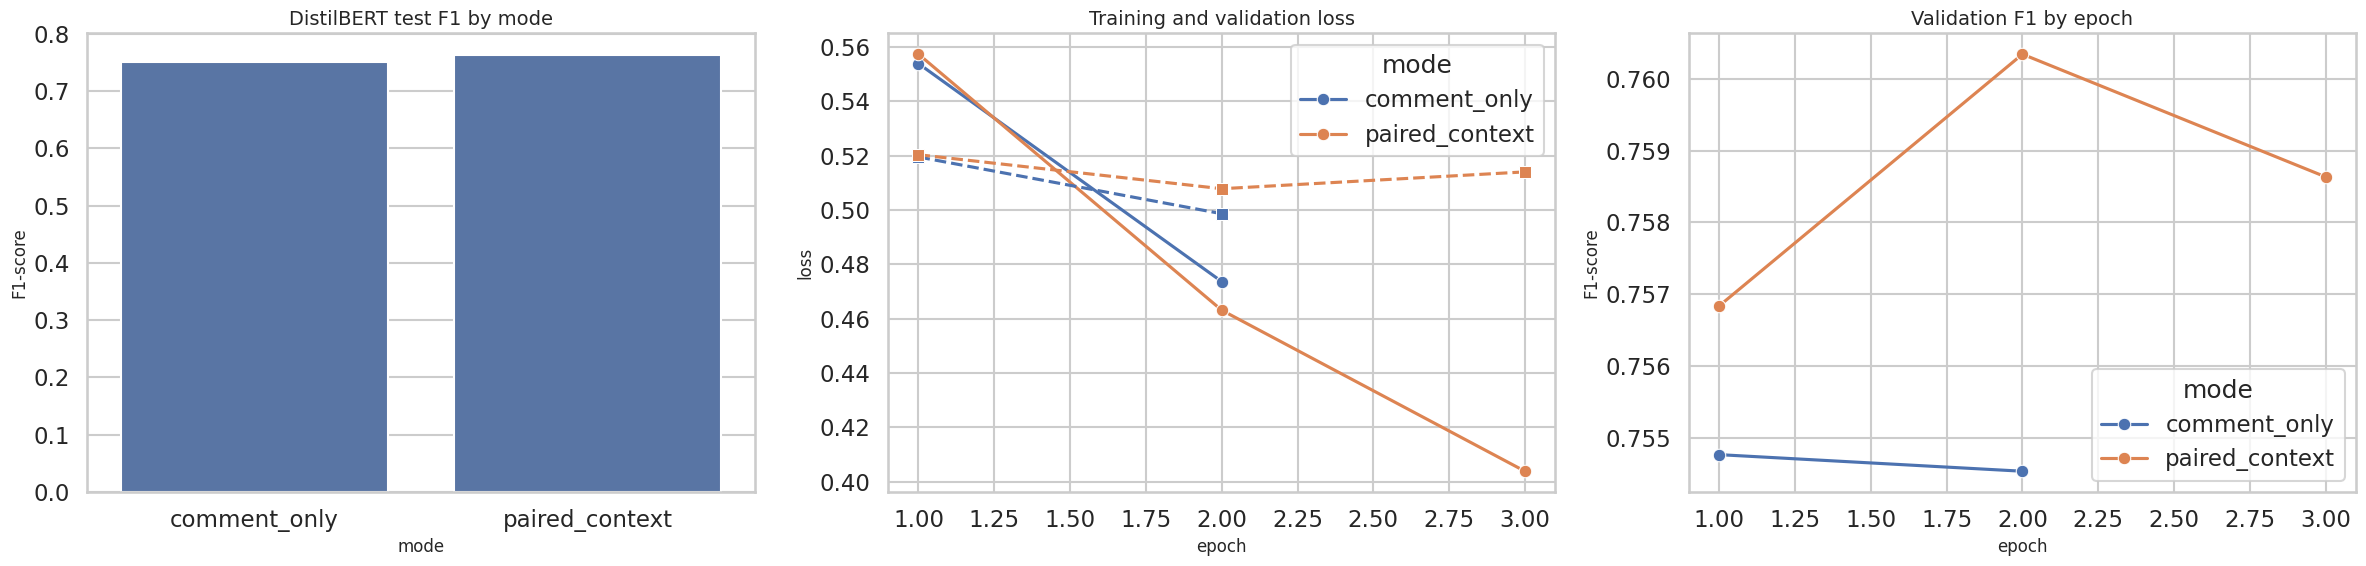

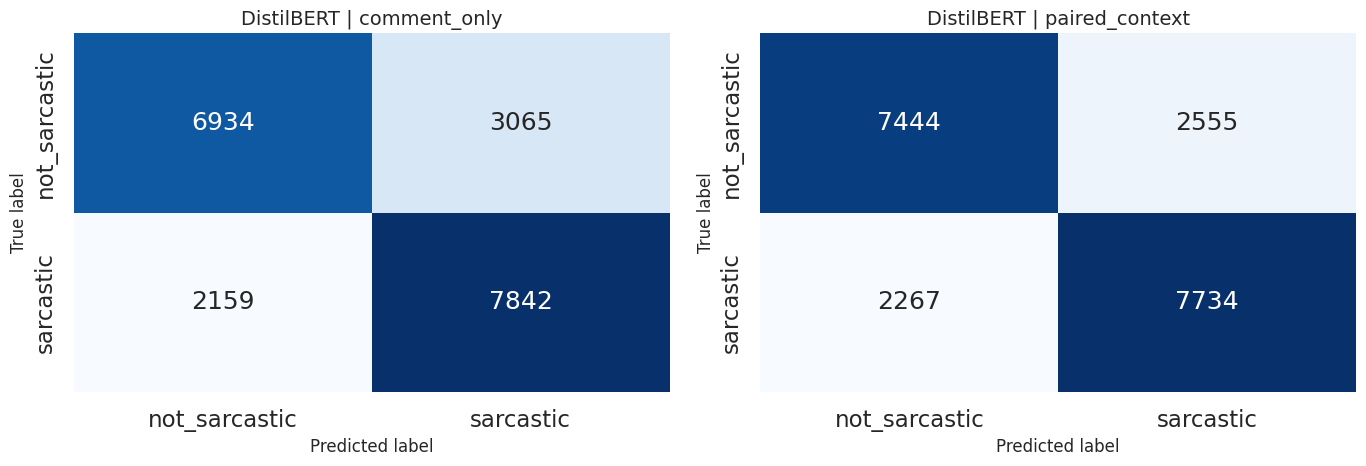

In [28]:
distilbert_history_df = pd.concat(
    [
        comment_only_artifact["history_df"],
        paired_context_artifact["history_df"],
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.barplot(
    data=distilbert_results_df[distilbert_results_df["split"] == "test"],
    x="mode",
    y="f1",
    order=MODE_ORDER,
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title("DistilBERT test F1 by mode")
axes[0].set_ylabel("F1-score")
axes[0].set_xlabel("mode")

sns.lineplot(
    data=distilbert_history_df,
    x="epoch",
    y="train_loss",
    hue="mode",
    marker="o",
    ax=axes[1],
)
sns.lineplot(
    data=distilbert_history_df,
    x="epoch",
    y="val_loss",
    hue="mode",
    marker="s",
    linestyle="--",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Training and validation loss")
axes[1].set_ylabel("loss")
axes[1].set_xlabel("epoch")

sns.lineplot(
    data=distilbert_history_df,
    x="epoch",
    y="val_f1",
    hue="mode",
    marker="o",
    ax=axes[2],
)
axes[2].set_title("Validation F1 by epoch")
axes[2].set_ylabel("F1-score")
axes[2].set_xlabel("epoch")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mode_name, artifact in zip(
    axes,
    MODE_ORDER,
    [comment_only_artifact, paired_context_artifact],
):
    test_frame = mode_split_frames[mode_name]["test"]
    show_confusion_matrix(
        test_frame["label"],
        artifact["predictions"]["test"],
        title=f"DistilBERT | {mode_name}",
        ax=ax,
    )
plt.tight_layout()
plt.show()


## 10. Brief Subreddit Analysis

The diagnostic below reports support counts and F1 values for the five most frequent subreddits in the shared test split.


In [29]:
shared_test_frame = sample_splits["test"].copy().reset_index(drop=True)
top_subreddits = shared_test_frame["subreddit"].value_counts().head(5).index.tolist()

subgroup_rows = []
for subreddit in top_subreddits:
    subgroup_mask = shared_test_frame["subreddit"] == subreddit
    subgroup_true = shared_test_frame.loc[subgroup_mask, "label"].to_numpy()
    subgroup_rows.append(
        {
            "subreddit": subreddit,
            "support": int(subgroup_mask.sum()),
            "mode": "comment_only",
            "f1": f1_score(
                subgroup_true,
                comment_only_artifact["predictions"]["test"][subgroup_mask.to_numpy()],
                zero_division=0,
            ),
        }
    )
    subgroup_rows.append(
        {
            "subreddit": subreddit,
            "support": int(subgroup_mask.sum()),
            "mode": "paired_context",
            "f1": f1_score(
                subgroup_true,
                paired_context_artifact["predictions"]["test"][subgroup_mask.to_numpy()],
                zero_division=0,
            ),
        }
    )

subreddit_analysis_df = pd.DataFrame(subgroup_rows)
subreddit_analysis_pivot_df = subreddit_analysis_df.pivot(
    index=["subreddit", "support"],
    columns="mode",
    values="f1",
).reset_index()

display(subreddit_analysis_df.style.format({"f1": "{:.4f}"}))
display(subreddit_analysis_pivot_df.style.format({"comment_only": "{:.4f}", "paired_context": "{:.4f}"}))


,subreddit,support,mode,f1
0,AskReddit,1273,comment_only,0.7117
1,AskReddit,1273,paired_context,0.7260
2,politics,745,comment_only,0.8441
3,politics,745,paired_context,0.8384
4,worldnews,544,comment_only,0.7939
5,worldnews,544,paired_context,0.8179
6,leagueoflegends,404,comment_only,0.8122
7,leagueoflegends,404,paired_context,0.8167
8,funny,383,comment_only,0.6798
9,funny,383,paired_context,0.6918


mode,subreddit,support,comment_only,paired_context
0,AskReddit,1273,0.7117,0.7260
1,funny,383,0.6798,0.6918
2,leagueoflegends,404,0.8122,0.8167
3,politics,745,0.8441,0.8384
4,worldnews,544,0.7939,0.8179


## 11. Error Analysis

The qualitative comparison covers:
- false positives and false negatives from the stronger DistilBERT mode
- cases where `paired_context` corrects a `comment_only` mistake
- cases where `paired_context` performs worse than `comment_only`


In [30]:
distilbert_test_rows = distilbert_results_df[distilbert_results_df["split"] == "test"].copy()
better_distilbert_row = distilbert_test_rows.sort_values("f1", ascending=False).iloc[0]
better_distilbert_mode = better_distilbert_row["mode"]
better_distilbert_artifact = (
    comment_only_artifact if better_distilbert_mode == "comment_only" else paired_context_artifact
)
better_distilbert_test_frame = mode_split_frames[better_distilbert_mode]["test"].copy().reset_index(drop=True)

better_mode_error_df = collect_error_cases(
    better_distilbert_test_frame,
    better_distilbert_artifact["predictions"]["test"],
    better_distilbert_artifact["probabilities"]["test"],
    model_name="DistilBERT",
    mode_name=better_distilbert_mode,
    top_n=8,
)

comparison_error_df = mode_split_frames["comment_only"]["test"][
    ["row_id", "label", "label_name", "subreddit", "score", "comment", "parent_comment"]
].copy().reset_index(drop=True)
comparison_error_df["comment_only_probability"] = comment_only_artifact["probabilities"]["test"]
comparison_error_df["comment_only_prediction"] = comment_only_artifact["predictions"]["test"]
comparison_error_df["paired_context_probability"] = paired_context_artifact["probabilities"]["test"]
comparison_error_df["paired_context_prediction"] = paired_context_artifact["predictions"]["test"]

comparison_error_df["comment_only_correct"] = (
    comparison_error_df["comment_only_prediction"] == comparison_error_df["label"]
)
comparison_error_df["paired_context_correct"] = (
    comparison_error_df["paired_context_prediction"] == comparison_error_df["label"]
)
comparison_error_df["comment_only_true_class_score"] = np.where(
    comparison_error_df["label"] == 1,
    comparison_error_df["comment_only_probability"],
    1.0 - comparison_error_df["comment_only_probability"],
)
comparison_error_df["paired_context_true_class_score"] = np.where(
    comparison_error_df["label"] == 1,
    comparison_error_df["paired_context_probability"],
    1.0 - comparison_error_df["paired_context_probability"],
)
comparison_error_df["paired_context_true_score_delta"] = (
    comparison_error_df["paired_context_true_class_score"]
    - comparison_error_df["comment_only_true_class_score"]
)

paired_context_fixes_df = (
    comparison_error_df[
        (~comparison_error_df["comment_only_correct"])
        & (comparison_error_df["paired_context_correct"])
    ]
    .sort_values("paired_context_true_score_delta", ascending=False)
    .head(6)
)
paired_context_worse_df = (
    comparison_error_df[
        (comparison_error_df["comment_only_correct"])
        & (~comparison_error_df["paired_context_correct"])
    ]
    .sort_values("paired_context_true_score_delta", ascending=True)
    .head(6)
)

display(
    better_mode_error_df[
        [
            "mode",
            "model",
            "error_type",
            "confidence",
            "label_name",
            "predicted_label_name",
            "subreddit",
            "score",
            "comment",
            "parent_comment",
        ]
    ].sort_values(["error_type", "confidence"], ascending=[True, False])
)
display(
    paired_context_fixes_df[
        [
            "row_id",
            "label_name",
            "subreddit",
            "comment_only_probability",
            "paired_context_probability",
            "paired_context_true_score_delta",
            "parent_comment",
            "comment",
        ]
    ]
)
display(
    paired_context_worse_df[
        [
            "row_id",
            "label_name",
            "subreddit",
            "comment_only_probability",
            "paired_context_probability",
            "paired_context_true_score_delta",
            "parent_comment",
            "comment",
        ]
    ]
)


,mode,model,error_type,confidence,label_name,predicted_label_name,subreddit,score,comment,parent_comment
8,paired_context,DistilBERT,false_negative,0.988541,sarcastic,not_sarcastic,Overwatch,32,"I've seen lots of them, though they always seem to be playing Soldier 76 for some reason.",Does anyone else feel like they have run into people using aim bots? I'm usually around 50-55 and I just can't imagine some of the people i've faced having such good aim and being stuck at that rank.
9,paired_context,DistilBERT,false_negative,0.984600,sarcastic,not_sarcastic,GlobalOffensive,-1,everything else than coming in last would be a huge disappointment.,"Wait until they come to Gfinity, until that you can't really say whether he was a good pickup or where C9 is heading"
10,paired_context,DistilBERT,false_negative,0.983369,sarcastic,not_sarcastic,dataisbeautiful,2,I dont have Prime but I find that really strange since the only Amazon service I actually use is AWS which is extremely user friendly,"It honestly boggles my mind that Amazon hasn't cleaned up their prime interface yet. I hear that complaint about it everywhere, so it's definitely not just a small number of people."
11,paired_context,DistilBERT,false_negative,0.982211,sarcastic,not_sarcastic,AskReddit,1,"They may be on opposite ends of the spectrum, but they're still on the spectrum.","No, I'm implying that IMO they are two opposites of a spectrum. Put together the combination works."
12,paired_context,DistilBERT,false_negative,0.981356,sarcastic,not_sarcastic,uncensorednews,10,"That is, far and away, the likeliest of scenarios.","If this is true this is disgusting. What's next? The DNC starts ""disappearing"" people from photos and records?"
13,paired_context,DistilBERT,false_negative,0.978817,sarcastic,not_sarcastic,Showerthoughts,1,Northern Lion.,Anna Bell?
14,paired_context,DistilBERT,false_negative,0.978659,sarcastic,not_sarcastic,CFB,-1,Every team uses it but it's the most intimidating when Vanderbilt plays it imo,Hell's Bells?
15,paired_context,DistilBERT,false_negative,0.978511,sarcastic,not_sarcastic,Bitcoin,27,"Pretty weird that this thread isn't banned yet, seeing as how XT is an altcoin and is off topic.",Today I reread the whitepaper: The XT manifesto might not be that consistent with Satoshi's original vision
0,paired_context,DistilBERT,false_positive,0.992495,not_sarcastic,sarcastic,The_Donald,2,Clearly racist,Milwaukee County Sheriff David Clarke requests mobilization of National Guard
1,paired_context,DistilBERT,false_positive,0.991605,not_sarcastic,sarcastic,todayilearned,1,"Yes, creating middle class jobs and fixing a broken economy definitely fucked us over.","No, he was just an old asshole who pretty much is responsible for wrecking the middle class over the last three decades. Or tell me, have tax cuts for the rich(wage stagnation), deregulation (2007-2008) and smaller g..."


,row_id,label_name,subreddit,comment_only_probability,paired_context_probability,paired_context_true_score_delta,parent_comment,comment
3307,163181,not_sarcastic,politics,0.955254,0.150400,0.804854,"Critics? It's time to get real, any realistic appraisal of Clinton vs. Trump comes up in Trump's favor. Maybe there was another candidate who could have done better against him but that's irrelevant now. Clinton fail...",We clearly watched two different shows
12102,610103,not_sarcastic,AdviceAnimals,0.851544,0.072017,0.779527,S,We did it reddit!
18757,950199,not_sarcastic,AskReddit,0.831015,0.118921,0.712093,"No, the gnomes take underwear.","Time to go to work, work all night Search for underpants, hey We won't stop 'til we have underpants yum yum yummy yum yay"
2407,117315,not_sarcastic,hearthstone,0.760063,0.055906,0.704156,\* [[Mountain Giants]],[[Boobie Giant]]
14510,732027,not_sarcastic,climbing,0.774338,0.072894,0.701443,"dont get too hung up on megapixels, 20MP is already a lot. what might matter is low light capabilities. how good your camera handles noise. lots of the bouldering I get to do is in dark forests.","Low light capabilities comes down to higher ISO ranges and functionality, right?"
7143,356533,not_sarcastic,bravefrontier,0.789957,0.112486,0.677471,"It doesn't matter too much right now as we just had the weekly reset, so you have the rest of the week to watch your score.",hmm... but what should i lookout for when the week ends?


,row_id,label_name,subreddit,comment_only_probability,paired_context_probability,paired_context_true_score_delta,parent_comment,comment
19256,974654,sarcastic,pics,0.851544,0.043918,-0.807626,"I beat Stage 2 of American Ninja Warrior Vegas Finals!! Thanks for the love Reddit! Sincerely, Weatherman Joe.",We did it reddit!
641,30456,not_sarcastic,politics,0.154659,0.937878,-0.783220,"So are a lot of the pro-Trump accounts here. More than a few of them already decided to reach this same conclusion. All at once. You know, as with most totally spontaneous, sincere opinions.","Things that make you go ""hmmmmm..."""
1528,73308,not_sarcastic,todayilearned,0.062536,0.816832,-0.754296,"To change who you are, you must first decide to love yourself. To love yourself, you must realize that you hate what you want. When you change what you do, you will love who you become. TL;DR: Don't choose to do some...",I've realized that and It came down like a ton of bricks so I've been kicking my ass into gear to get shit done but it just keeps going on and on and it's disheartening to see everyone else doing it so seemingly easy...
12475,629159,sarcastic,leagueoflegends,0.828302,0.106336,-0.721966,I got to play with Faker and Marin and PAX Prime and made a pretty awesome play.,such skill 10/10 imo
19034,963587,not_sarcastic,technology,0.189808,0.889027,-0.699219,"Norway makes over $50 billion a year in oil revenue that they put in a trust fund for a population of a little over 9 million. To put that in perspective, that would be like the U.S. having over $1.5 *Trillion* in re...",Norway sure is rich but not that much compared to USA (GDP/capita) yet USA is over twice as dense as Norway in population.
4408,215360,sarcastic,baseball,0.742695,0.063777,-0.678918,Aledmys Diaz makes incredible over-the-shoulder catch,Should have been infield fly IMO


## 12. Conclusions

The closing section summarizes:
- whether pretrained `comment_only` exceeds the saved `BiLSTM` benchmark (`F1 = 0.7225`)
- whether paired-input context helps relative to pretrained `comment_only`
- whether DistilBERT becomes the strongest Reddit result in the project


In [31]:
best_prior_comment_only_f1 = float(best_prior_comment_only_row["f1"])
distilbert_comment_only_f1 = float(distilbert_comment_only_row["f1"])
distilbert_paired_context_f1 = float(distilbert_paired_context_row["f1"])
best_distilbert_test_row = distilbert_test_rows.sort_values("f1", ascending=False).iloc[0]
best_distilbert_mode = best_distilbert_test_row["mode"]
best_distilbert_f1 = float(best_distilbert_test_row["f1"])

comment_only_delta = distilbert_comment_only_f1 - best_prior_comment_only_f1
paired_context_delta = distilbert_paired_context_f1 - distilbert_comment_only_f1

if comment_only_delta > 0.01:
    pretrained_takeaway = (
        f"Yes. DistilBERT `comment_only` beats the best prior non-pretrained `comment_only` baseline "
        f"by {comment_only_delta:.4f} F1, which is a clear improvement over the saved BiLSTM benchmark."
    )
elif comment_only_delta > 0:
    pretrained_takeaway = (
        f"Yes, but only slightly. DistilBERT `comment_only` improves on the saved BiLSTM benchmark by "
        f"{comment_only_delta:.4f} F1, so the report should describe the gain as modest."
    )
else:
    pretrained_takeaway = (
        f"No. DistilBERT `comment_only` does not beat the saved BiLSTM benchmark; it trails by "
        f"{abs(comment_only_delta):.4f} F1."
    )

if paired_context_delta > 0.01:
    context_takeaway = (
        f"Proper paired-input context helps meaningfully: `paired_context` improves on DistilBERT "
        f"`comment_only` by {paired_context_delta:.4f} F1."
    )
elif paired_context_delta > 0:
    context_takeaway = (
        f"Proper paired-input context helps, but only slightly: the gain over DistilBERT `comment_only` "
        f"is {paired_context_delta:.4f} F1."
    )
else:
    context_takeaway = (
        f"Proper paired-input context does not help here. The change relative to DistilBERT `comment_only` "
        f"is {paired_context_delta:.4f} F1, so the report should say that naive concatenation failed first "
        f"and paired input still did not justify context for this setup."
    )

if best_distilbert_f1 > best_prior_comment_only_f1:
    recommendation = (
        "Use this DistilBERT notebook as the new main report result, while keeping the earlier custom Reddit "
        "notebook as the non-pretrained reference point."
    )
else:
    recommendation = (
        "Keep the earlier custom Reddit notebook as the main report result and present this DistilBERT run as "
        "the pretrained follow-up that did not clearly improve the benchmark."
    )

summary_markdown = dedent(
    f"""
    **Best DistilBERT mode:** `{best_distilbert_mode}` with test F1 = `{best_distilbert_f1:.4f}`.

    **Does pretrained `comment_only` beat the saved BiLSTM benchmark (`0.7225`)?** {pretrained_takeaway}

    **Does paired-input context help?** {context_takeaway}

    **Should this pretrained notebook become the new main report result?** {recommendation}
    """
)

display(Markdown(summary_markdown))

report_summary = {
    "best_distilbert_mode": best_distilbert_mode,
    "best_distilbert_test_f1": round(best_distilbert_f1, 4),
    "distilbert_comment_only_test_f1": round(distilbert_comment_only_f1, 4),
    "distilbert_paired_context_test_f1": round(distilbert_paired_context_f1, 4),
    "best_prior_comment_only_model": best_prior_comment_only_row["model"],
    "best_prior_comment_only_f1": round(best_prior_comment_only_f1, 4),
    "distilbert_comment_only_minus_best_prior_comment_only": round(comment_only_delta, 4),
    "distilbert_paired_context_minus_comment_only": round(paired_context_delta, 4),
    "recommendation": recommendation,
}

report_summary



**Best DistilBERT mode:** `paired_context` with test F1 = `0.7623`.

**Does pretrained `comment_only` beat the saved BiLSTM benchmark (`0.7225`)?** Yes. DistilBERT `comment_only` beats the best prior non-pretrained `comment_only` baseline by 0.0276 F1, which is a clear improvement over the saved BiLSTM benchmark.

**Does paired-input context help?** Proper paired-input context helps meaningfully: `paired_context` improves on DistilBERT `comment_only` by 0.0122 F1.

**Should this pretrained notebook become the new main report result?** Use this DistilBERT notebook as the new main report result, while keeping the earlier custom Reddit notebook as the non-pretrained reference point.


{'best_distilbert_mode': 'paired_context',
 'best_distilbert_test_f1': 0.7623,
 'distilbert_comment_only_test_f1': 0.7501,
 'distilbert_paired_context_test_f1': 0.7623,
 'best_prior_comment_only_model': 'Bidirectional LSTM',
 'best_prior_comment_only_f1': 0.7225,
 'distilbert_comment_only_minus_best_prior_comment_only': 0.0276,
 'distilbert_paired_context_minus_comment_only': 0.0122,
 'recommendation': 'Use this DistilBERT notebook as the new main report result, while keeping the earlier custom Reddit notebook as the non-pretrained reference point.'}